# STOCK TREND REGRESSION PROJECT

### Colecting and Storing the Data

Libraries Required

In [1]:
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib

from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    mean_absolute_error,
    r2_score,
    root_mean_squared_error
)

Downloading the data of multiple stocks to train the model on it

In [2]:
stocks = ['AAPL', 'MSFT', 'TSLA', 'NVDA', 'AMZN']

all_data = []

for stock in stocks:

    data = yf.download(stock, period='5y')

    data.columns = data.columns.get_level_values(0)

    data['Ticker'] = stock

    all_data.append(data)


[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed
[*********************100%***********************]  1 of 1 completed


Combining the Data

In [3]:
combined_data = pd.concat(all_data)

# Reset index
combined_data.reset_index(inplace=True)

print(combined_data.head())

Price       Date       Close        High         Low        Open    Volume  \
0     2021-05-24  123.890961  124.709756  122.760252  122.828485  63092900   
1     2021-05-25  123.696037  125.080191  123.130679  124.592807  72009500   
2     2021-05-26  123.647285  124.173652  123.228142  123.754509  56575900   
3     2021-05-27  122.116913  124.417328  121.921965  123.247629  94625600   
4     2021-05-28  121.463814  122.623771  121.405331  122.399575  71311100   

Price Ticker  
0       AAPL  
1       AAPL  
2       AAPL  
3       AAPL  
4       AAPL  


### Data Info

In [4]:
print("\n=========================")
print("DATASET INFORMATION")
print("=========================")

print("\nFirst 5 rows:")
print(combined_data.head())

print("\nDataset Shape:")
print(combined_data.shape)

print("\nColumns:")
print(combined_data.columns)

print("\nData Types:")
print(combined_data.dtypes)

print("\nMissing Values:")
print(combined_data.isnull().sum())

print("\nStatistical Summary:")
print(combined_data.describe())


DATASET INFORMATION

First 5 rows:
Price       Date       Close        High         Low        Open    Volume  \
0     2021-05-24  123.890961  124.709756  122.760252  122.828485  63092900   
1     2021-05-25  123.696037  125.080191  123.130679  124.592807  72009500   
2     2021-05-26  123.647285  124.173652  123.228142  123.754509  56575900   
3     2021-05-27  122.116913  124.417328  121.921965  123.247629  94625600   
4     2021-05-28  121.463814  122.623771  121.405331  122.399575  71311100   

Price Ticker  
0       AAPL  
1       AAPL  
2       AAPL  
3       AAPL  
4       AAPL  

Dataset Shape:
(6275, 7)

Columns:
Index(['Date', 'Close', 'High', 'Low', 'Open', 'Volume', 'Ticker'], dtype='str', name='Price')

Data Types:
Price
Date      datetime64[s]
Close           float64
High            float64
Low             float64
Open            float64
Volume            int64
Ticker              str
dtype: object

Missing Values:
Price
Date      0
Close     0
High      0
Low       0
Op

### Raw data Visualization

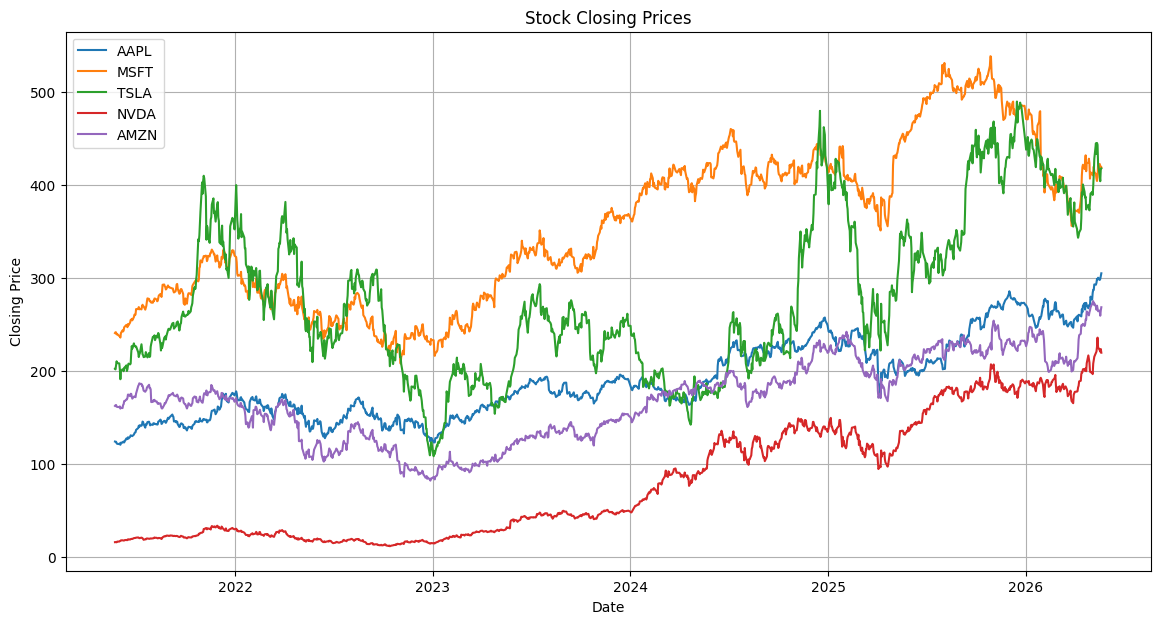

In [5]:
plt.figure(figsize=(14,7))

for stock in stocks:

    stock_data = combined_data[
        combined_data['Ticker'] == stock
    ]

    plt.plot(
        stock_data['Date'],
        stock_data['Close'],
        label=stock
    )

plt.title("Stock Closing Prices")

plt.xlabel("Date")

plt.ylabel("Closing Price")

plt.legend()

plt.grid(True)

plt.show()

### Feature Engineering

Creating reqiured features:
1. Daily Return ---------------- (Today's movement of the stock)
2. Lag Features ---------------- (Previous Day's movement)
3. Moving Average -------------- (Short term trend)
4. Volatility ------------------ (Market Instability)
5. Volume Moving Average ------- (Average Traded Shares)

In [6]:
# Daily Return
combined_data['Return'] = combined_data['Close'].pct_change()

# Lag Features
combined_data['Lag1'] = combined_data['Return'].shift(1)
combined_data['Lag2'] = combined_data['Return'].shift(2)

# Moving Average
combined_data['MA5'] = combined_data['Close'].rolling(window=5).mean()

# Volatility
combined_data['Volatility'] = (
    combined_data['Return']
    .rolling(window=5)
    .std()
)

# Volume Moving Average
combined_data['Volume_MA5'] = (
    combined_data['Volume']
    .rolling(window=5)
    .mean()
)

### Creating Target Variable

In [7]:
combined_data['Target'] = (
    combined_data['Return']
    .shift(-1)
)

### Cleaning Data

In [8]:
combined_data = combined_data.dropna()

### Choosing Features

In [9]:
features = [
    'Return',
    'Lag1',
    'Lag2',
    'MA5',
    'Volatility',
    'Volume_MA5'
]

X = combined_data[features]

y = combined_data['Target']

### Feature Scaling

In [10]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

### Splitting the Data into Train and Test

In [11]:
split_index = int(len(combined_data) * 0.8)

X_train = X_scaled[:split_index]
X_test = X_scaled[split_index:]

y_train = y[:split_index]
y_test = y[split_index:]

print(f"Training Samples: {len(X_train)}")

print(f"Testing Samples: {len(X_test)}")

Training Samples: 5015
Testing Samples: 1254


### Traning the Model

In [12]:
model = LinearRegression()

model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### Predictions

In [13]:
predictions = model.predict(X_test)

### Evaluation of the model

In [14]:
mae = mean_absolute_error(
    y_test,
    predictions
)

rmse = root_mean_squared_error(
    y_test,
    predictions
)

r2 = r2_score(
    y_test,
    predictions
)

mape = np.mean(
    np.abs((y_test - predictions) / y_test)
) * 100

print(f"MAE  : {mae:.6f}")

print(f"RMSE : {rmse:.6f}")

print(f"R²   : {r2:.4f}")

print(f"MAPE : {mape:.2f}%")

MAE  : 0.016013
RMSE : 0.022351
R²   : -0.0031
MAPE : inf%


### Visualizing Predictions

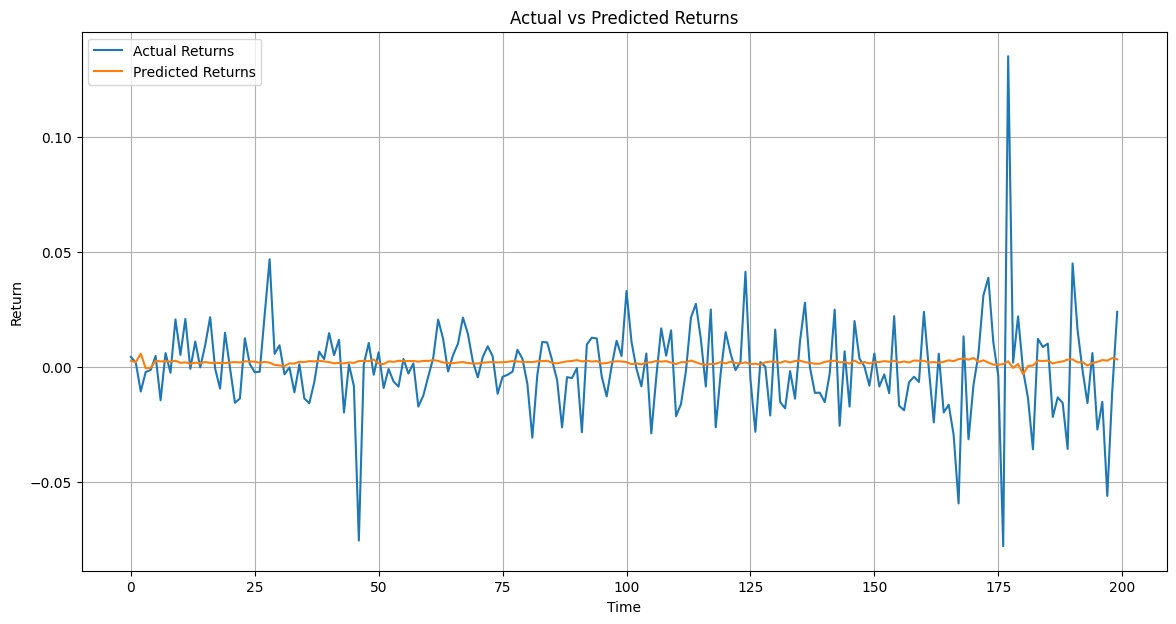

In [15]:
plt.figure(figsize=(14,7))

plt.plot(
    y_test.values[:200],
    label='Actual Returns'
)

plt.plot(
    predictions[:200],
    label='Predicted Returns'
)

plt.title("Actual vs Predicted Returns")

plt.xlabel("Time")

plt.ylabel("Return")

plt.legend()

plt.grid(True)

plt.show()

### Saving the model and scaler

In [16]:
joblib.dump(
    model,
    '../models/stock_model.pkl'
)

joblib.dump(
    scaler,
    '../models/scaler.pkl'
)

print("\nModel and scaler saved successfully.")


Model and scaler saved successfully.
